# 2.3 Backtest Engine — rolling-universe baseline only

This notebook completes **Section 2.3** as a continuation of the **enhanced Section 2.1** rolling full-universe setup and the **baseline Section 2.2** fitting notebook.

Important:

- We continue from the **2.1 rolling full-universe enhancement**.
- We do **not** add any 2.2 enhancement. The only model inputs are the baseline `OW_transient` and `reduced_form` parameter files from Section 2.2.
- We do **not** add any 2.3 enhancement. The simulator resets positions and impact states at the start of each trading day. There is no multi-day state tracking and no stock-split logic.

The engine processes a generic signed trade column called `our_trade`. For the baseline demonstration, the notebook creates a simple daily round-trip schedule: buy near the open and sell near the close. This is only to demonstrate the engine; it is not an optimal strategy and not an alpha.

## 0. Setup

Run these first:

1. `2_1_full_as_spec_completed.ipynb`
2. `2_2_rolling_baseline_no_enhancement.ipynb`

This notebook expects their outputs under `/content/project_data`.

In [19]:
!pip -q install pyarrow

import os
import gc
import json
import math
import shutil
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)

In [20]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
LOCAL_BASE = Path("/content/project_data")

DRIVE_PROJECT_DATA = Path(
    "/content/drive/MyDrive/Quantitative Trading and Price Impact/project_data"
)

DRIVE_PROCESSED_21 = DRIVE_PROJECT_DATA / "processed_2_1"
DRIVE_PROCESSED_22 = DRIVE_PROJECT_DATA / "processed_2_2_rolling_baseline"

SECTION21_DIR = LOCAL_BASE / "processed_2_1"
MONTHLY21_DIR = SECTION21_DIR / "monthly_standardised"
ROLLING21_DIR = SECTION21_DIR / "rolling_full_universe"

SECTION22_DIR = LOCAL_BASE / "processed_2_2_rolling_baseline"
PARAM22_DIR = SECTION22_DIR / "parameters"

SECTION23_DIR = LOCAL_BASE / "processed_2_3_rolling_baseline"
DAILY_DIR = SECTION23_DIR / "daily_summaries"
TRADE_LOG_DIR = SECTION23_DIR / "trade_logs"
REPORT_DIR = SECTION23_DIR / "report_tables"
FIG_DIR = SECTION23_DIR / "figures"
LOG_DIR = SECTION23_DIR / "logs"

# Restore 2.1 outputs
if not ROLLING21_DIR.exists():
    print("Restoring 2.1 outputs from Drive...")
    if not DRIVE_PROCESSED_21.exists():
        raise FileNotFoundError(f"Missing 2.1 Drive folder: {DRIVE_PROCESSED_21}")
    shutil.copytree(DRIVE_PROCESSED_21, SECTION21_DIR, dirs_exist_ok=True)

# Restore 2.2 outputs
if not PARAM22_DIR.exists():
    print("Restoring 2.2 outputs from Drive...")
    if not DRIVE_PROCESSED_22.exists():
        raise FileNotFoundError(f"Missing 2.2 Drive folder: {DRIVE_PROCESSED_22}")
    shutil.copytree(DRIVE_PROCESSED_22, SECTION22_DIR, dirs_exist_ok=True)

for p in [SECTION23_DIR, DAILY_DIR, TRADE_LOG_DIR, REPORT_DIR, FIG_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("2.1 rolling folder:", ROLLING21_DIR)
print("2.1 monthly folder:", MONTHLY21_DIR)
print("2.2 parameter folder:", PARAM22_DIR)
print("2.3 output folder:", SECTION23_DIR)

print("\n2.1 rolling files:")
for p in ROLLING21_DIR.glob("*"):
    print(p.name)

print("\n2.2 parameter files:")
for p in PARAM22_DIR.glob("*"):
    print(p.name)

2.1 rolling folder: /content/project_data/processed_2_1/rolling_full_universe
2.1 monthly folder: /content/project_data/processed_2_1/monthly_standardised
2.2 parameter folder: /content/project_data/processed_2_2_rolling_baseline/parameters
2.3 output folder: /content/project_data/processed_2_3_rolling_baseline

2.1 rolling files:
rolling_pair_summary.csv
rolling_universe_by_pair.csv
global_common_universe_all_months.csv
section_2_1_rolling_config.json

2.2 parameter files:
params_pair_01_201901_to_201902.csv
params_pair_10_201910_to_201911.csv
params_pair_03_201903_to_201904.csv
ow_transient_params_by_pair_stock.csv
params_pair_11_201911_to_201912.csv
params_pair_07_201907_to_201908.csv
params_pair_05_201905_to_201906.csv
reduced_form_params_by_pair_stock.csv
section_2_2_rolling_baseline_params_all_pairs.csv
params_pair_06_201906_to_201907.csv
params_pair_04_201904_to_201905.csv
params_pair_02_201902_to_201903.csv
params_pair_09_201909_to_201910.csv
params_pair_08_201908_to_201909.csv

## 1. Load Section 2.1 and Section 2.2 handoff files

This is where we make sure we are using the enhanced 2.1 rolling full-universe setup, not the 20-stock baseline.

In [22]:
pair_summary_path = ROLLING21_DIR / "rolling_pair_summary.csv"
universe_path = ROLLING21_DIR / "rolling_universe_by_pair.csv"
ow_param_path = PARAM22_DIR / "ow_transient_params_by_pair_stock.csv"
rf_param_path = PARAM22_DIR / "reduced_form_params_by_pair_stock.csv"

required = [pair_summary_path, universe_path, ow_param_path, rf_param_path]
missing = [p for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing required files. Run enhanced 2.1 and then 2_2_rolling_baseline_no_enhancement.ipynb first. Missing:\n" +
        "\n".join(str(p) for p in missing)
    )

pair_summary = pd.read_csv(pair_summary_path)
pair_universe = pd.read_csv(universe_path)
ow_params = pd.read_csv(ow_param_path)
rf_params = pd.read_csv(rf_param_path)

for df in [pair_summary, pair_universe, ow_params, rf_params]:
    if "train_month" in df.columns:
        df["train_month"] = df["train_month"].astype(str)
    if "test_month" in df.columns:
        df["test_month"] = df["test_month"].astype(str)
    if "stock" in df.columns:
        df["stock"] = df["stock"].astype(str)

print("Rolling pairs:")
display(pair_summary[["pair_id", "train_month", "test_month"]])

print("Full universe size by pair:")
display(pair_universe.groupby("pair_id")["stock"].nunique().reset_index(name="n_full_universe_stocks"))

print("OW parameter rows:", ow_params.shape)
print("Reduced-form parameter rows:", rf_params.shape)
print("Confirmed: this notebook does not select top-20 stocks.")

Rolling pairs:


,pair_id,train_month,test_month
0,1,201901,201902
1,2,201902,201903
2,3,201903,201904
3,4,201904,201905
4,5,201905,201906
5,6,201906,201907
6,7,201907,201908
7,8,201908,201909
8,9,201909,201910
9,10,201910,201911


Full universe size by pair:


,pair_id,n_full_universe_stocks
0,1,50
1,2,50
2,3,50
3,4,50
4,5,50
5,6,50
6,7,50
7,8,49
8,9,49
9,10,49


OW parameter rows: (546, 15)
Reduced-form parameter rows: (546, 15)
Confirmed: this notebook does not select top-20 stocks.


## 2. Run controls

Keep `RUN_PAIR_IDS = None` and `MAX_STOCKS_PER_PAIR = None` for the final run. The optional controls are only there so you can debug one pair quickly in Colab.

In [23]:
RUN_PAIR_IDS: Optional[List[int]] = None       # example for debugging: [1]
MAX_STOCKS_PER_PAIR: Optional[int] = None     # keep None for full universe; do not set to 20

# Generic baseline trade schedule.
PARTICIPATION_RATE = 0.005        # 0.5% of each stock-day public absolute volume
MIN_TARGET_SHARES = 1.0
OPEN_WINDOW_SECONDS = 30 * 60
CLOSE_WINDOW_SECONDS = 30 * 60
ROUND_LOT = 1.0

SAVE_NONZERO_TRADE_LOGS = True
SAVE_MAX_TRADE_LOG_ROWS_PER_PAIR = 300_000

BIN_COLUMNS_NEEDED = [
    "date", "time", "stock", "trade", "orderFlow", "hidden", "auction",
    "mid", "midEnd", "spread", "lobImb", "effLobImb", "depth",
    "datetime", "trading_date", "seconds_from_open"
]

## 3. Loading and preparation utilities

We recompute the train-month order-flow scale used by 2.2, then use it when simulating the test month.

In [24]:
def monthly_bin_path(month: str) -> Path:
    return MONTHLY21_DIR / "bin" / f"bin_{str(month)}_standardised.parquet"


def load_bin_month_for_universe(month: str, stocks: List[str], columns: Optional[List[str]] = None) -> pd.DataFrame:
    path = monthly_bin_path(month)
    if not path.exists():
        raise FileNotFoundError(f"Missing monthly bin Parquet for {month}: {path}")
    try:
        df = pd.read_parquet(path, columns=columns, filters=[("stock", "in", list(stocks))])
    except Exception:
        df = pd.read_parquet(path, columns=columns)
        df["stock"] = df["stock"].astype(str)
        df = df[df["stock"].isin(set(stocks))].copy()
    df["stock"] = df["stock"].astype(str)
    return df.reset_index(drop=True)


def get_pair_stock_universe(pair_id: int) -> List[str]:
    stocks = (
        pair_universe.loc[pair_universe["pair_id"] == pair_id, "stock"]
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .tolist()
    )
    if MAX_STOCKS_PER_PAIR is not None:
        stocks = stocks[:MAX_STOCKS_PER_PAIR]
    return stocks


def make_seconds_from_open(df: pd.DataFrame) -> pd.Series:
    dt = pd.to_datetime(df["datetime"])
    open_time = pd.to_datetime(dt.dt.date.astype(str) + " 09:30:00")
    return (dt - open_time).dt.total_seconds().astype("float64")


def compute_training_scales(train_df: pd.DataFrame) -> Dict:
    tmp = train_df.copy()
    tmp["stock"] = tmp["stock"].astype(str)
    tmp["trading_date"] = tmp["trading_date"].astype(str)
    tmp["abs_orderFlow"] = pd.to_numeric(tmp["orderFlow"], errors="coerce").abs()

    daily_abs_flow = (
        tmp.groupby(["stock", "trading_date"], observed=True)["abs_orderFlow"]
        .sum()
        .reset_index(name="daily_abs_orderFlow")
    )
    stock_flow_scale = daily_abs_flow.groupby("stock", observed=True)["daily_abs_orderFlow"].median().replace(0, np.nan)
    global_flow_scale = float(np.nanmedian(stock_flow_scale.values))
    if not np.isfinite(global_flow_scale) or global_flow_scale <= 0:
        global_flow_scale = 1.0
    stock_flow_scale = stock_flow_scale.fillna(global_flow_scale).to_dict()

    median_depth = tmp.groupby("stock", observed=True)["depth"].median().replace(0, np.nan)
    global_depth_scale = float(np.nanmedian(median_depth.values))
    if not np.isfinite(global_depth_scale) or global_depth_scale <= 0:
        global_depth_scale = 1.0
    median_depth = median_depth.fillna(global_depth_scale).to_dict()

    return {
        "stock_flow_scale": {str(k): float(v) for k, v in stock_flow_scale.items()},
        "global_flow_scale": float(global_flow_scale),
        "stock_depth_scale": {str(k): float(v) for k, v in median_depth.items()},
        "global_depth_scale": float(global_depth_scale),
    }


def prepare_market_frame(df: pd.DataFrame, scales: Dict) -> pd.DataFrame:
    out = df.copy()
    out["stock"] = out["stock"].astype(str)
    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out["trading_date"] = out["trading_date"].astype(str)
    if "seconds_from_open" not in out.columns:
        out["seconds_from_open"] = make_seconds_from_open(out)

    out = out[out["datetime"].notna()].copy()
    out = out[(pd.to_numeric(out["mid"], errors="coerce") > 0)].copy()
    out = out.replace([np.inf, -np.inf], np.nan)

    out["mid"] = pd.to_numeric(out["mid"], errors="coerce")
    out["midEnd"] = pd.to_numeric(out["midEnd"], errors="coerce").fillna(out["mid"])
    out["spread"] = pd.to_numeric(out["spread"], errors="coerce").fillna(0.0)
    out["depth"] = pd.to_numeric(out["depth"], errors="coerce").replace(0, np.nan)
    out["trade"] = pd.to_numeric(out["trade"], errors="coerce").fillna(0.0)
    out["orderFlow"] = pd.to_numeric(out["orderFlow"], errors="coerce").fillna(0.0)

    out["spread_bps"] = 10000.0 * out["spread"] / out["mid"]
    out["spread_bps"] = out["spread_bps"].replace([np.inf, -np.inf], np.nan).fillna(0.0)

    out["flow_scale"] = out["stock"].map(scales["stock_flow_scale"]).fillna(scales["global_flow_scale"]).astype(float)
    out["depth_scale"] = out["stock"].map(scales["stock_depth_scale"]).fillna(scales["global_depth_scale"]).astype(float)

    return out.sort_values(["stock", "trading_date", "datetime"]).reset_index(drop=True)

## 4. Generic daily round-trip trades

The backtest engine must process generic trades. Since alphas and optimal strategies come later, we use a basic deterministic schedule here.

In [25]:
def round_to_lot(x: float, lot: float = 1.0) -> float:
    if lot is None or lot <= 1:
        return float(x)
    return float(round(x / lot) * lot)


def choose_open_close_indices(day_df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
    seconds = pd.to_numeric(day_df["seconds_from_open"], errors="coerce").to_numpy(dtype=float)
    if np.isfinite(seconds).sum() < 4:
        return np.array([], dtype=int), np.array([], dtype=int)

    max_sec = np.nanmax(seconds)
    open_pos = np.where(seconds <= OPEN_WINDOW_SECONDS)[0]
    close_pos = np.where(seconds >= max_sec - CLOSE_WINDOW_SECONDS)[0]

    if len(open_pos) == 0 or len(close_pos) == 0 or len(set(open_pos).intersection(set(close_pos))) > 0:
        n = len(day_df)
        k = max(1, int(0.2 * n))
        open_pos = np.arange(0, k)
        close_pos = np.arange(n - k, n)

    return open_pos.astype(int), close_pos.astype(int)


def add_daily_round_trip_trades(stock_df: pd.DataFrame) -> pd.DataFrame:
    out = stock_df.sort_values(["trading_date", "datetime"]).reset_index(drop=True).copy()
    out["our_trade"] = 0.0

    for _, idx in out.groupby("trading_date", observed=True, sort=False).indices.items():
        day = out.iloc[idx].copy()
        if len(day) < 4:
            continue

        abs_public_volume = float(pd.to_numeric(day["trade"], errors="coerce").abs().sum())
        if not np.isfinite(abs_public_volume) or abs_public_volume <= 0:
            abs_public_volume = float(pd.to_numeric(day["orderFlow"], errors="coerce").abs().sum())

        target_shares = round_to_lot(PARTICIPATION_RATE * abs_public_volume, ROUND_LOT)
        if not np.isfinite(target_shares) or target_shares < MIN_TARGET_SHARES:
            continue

        open_pos, close_pos = choose_open_close_indices(day)
        if len(open_pos) == 0 or len(close_pos) == 0:
            continue

        global_open_idx = np.asarray(idx)[open_pos]
        global_close_idx = np.asarray(idx)[close_pos]

        out.loc[global_open_idx, "our_trade"] += target_shares / len(global_open_idx)
        out.loc[global_close_idx, "our_trade"] -= target_shares / len(global_close_idx)

    return out

## 5. Simulator

The simulator resets inside each stock-day loop. That is the baseline 2.3 behaviour.

In [26]:
def param_value(param_row: pd.Series, name: str, default: float = 0.0) -> float:
    if name not in param_row.index:
        return float(default)
    value = param_row[name]
    if pd.isna(value):
        return float(default)
    return float(value)


def daily_summary_from_path(path_df: pd.DataFrame, model: str) -> Dict:
    nonzero = path_df[path_df["our_trade"].abs() > 0].copy()
    if len(path_df) == 0:
        return {}

    first = path_df.iloc[0]
    last = path_df.iloc[-1]
    gross_shares = float(nonzero["our_trade"].abs().sum()) if len(nonzero) else 0.0
    net_shares = float(nonzero["our_trade"].sum()) if len(nonzero) else 0.0
    turnover_notional = float((nonzero["our_trade"].abs() * nonzero["mid"]).sum()) if len(nonzero) else 0.0

    return {
        "pair_id": int(first["pair_id"]),
        "train_month": str(first["train_month"]),
        "test_month": str(first["test_month"]),
        "model": model,
        "stock": str(first["stock"]),
        "trading_date": str(first["trading_date"]),
        "n_market_rows": int(len(path_df)),
        "n_our_trade_rows": int((path_df["our_trade"].abs() > 0).sum()),
        "gross_shares": gross_shares,
        "net_shares": net_shares,
        "turnover_notional": turnover_notional,
        "final_inventory": float(last["inventory"]),
        "final_cash": float(last["cash"]),
        "final_portfolio_value": float(last["portfolio_value"]),
        "execution_shortfall": float(path_df["execution_shortfall"].sum()),
        "spread_cost": float(path_df["spread_cost"].sum()),
        "impact_cost": float(path_df["impact_cost"].sum()),
        "max_abs_inventory": float(path_df["inventory"].abs().max()),
        "max_abs_impact_bps": float(path_df["impact_bps"].abs().max()),
        "max_abs_impact_state": float(path_df["impact_state_post"].abs().max()),
        "first_mid": float(first["mid"]),
        "last_mid": float(last["midEnd"]),
    }


def simulate_stock_day_ow(day_df: pd.DataFrame, param_row: pd.Series) -> Tuple[pd.DataFrame, Dict]:
    d = day_df.sort_values("datetime").reset_index(drop=True).copy()

    beta_flow = param_value(param_row, "x_flow", 0.0)
    beta_state = param_value(param_row, "ow_state_pre", 0.0)
    half_life_sec = param_value(param_row, "half_life_sec", 300.0)
    if not np.isfinite(half_life_sec) or half_life_sec <= 0:
        half_life_sec = 300.0
    tau = half_life_sec / math.log(2.0)

    n = len(d)
    state_pre_arr = np.zeros(n)
    state_post_arr = np.zeros(n)
    impact_bps_arr = np.zeros(n)
    exec_price_arr = np.full(n, np.nan)
    cash_arr = np.zeros(n)
    inventory_arr = np.zeros(n)
    shortfall_arr = np.zeros(n)
    spread_cost_arr = np.zeros(n)
    impact_cost_arr = np.zeros(n)
    portfolio_value_arr = np.zeros(n)

    state = 0.0
    inventory = 0.0
    cash = 0.0
    prev_sec = None

    seconds = pd.to_numeric(d["seconds_from_open"], errors="coerce").to_numpy(dtype=float)
    mids = pd.to_numeric(d["mid"], errors="coerce").to_numpy(dtype=float)
    mid_ends = pd.to_numeric(d["midEnd"], errors="coerce").fillna(d["mid"]).to_numpy(dtype=float)
    spreads_bps = pd.to_numeric(d["spread_bps"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    flow_scales = pd.to_numeric(d["flow_scale"], errors="coerce").replace(0, np.nan).fillna(1.0).to_numpy(dtype=float)
    trades = pd.to_numeric(d["our_trade"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

    for i in range(n):
        sec = seconds[i]
        dt = 0.0 if prev_sec is None or not np.isfinite(sec) or not np.isfinite(prev_sec) else max(0.0, sec - prev_sec)
        phi = math.exp(-dt / tau) if tau > 0 else 0.0
        state_pre = phi * state

        q = trades[i]
        mid = mids[i]
        mid_end = mid_ends[i]
        side = np.sign(q)
        x_own = q / flow_scales[i] if flow_scales[i] != 0 else 0.0

        # Own-trade impact only: intercept is not charged as execution impact.
        impact_bps = beta_flow * x_own + beta_state * state_pre
        exec_price = np.nan
        spread_cost = 0.0
        impact_cost = 0.0
        shortfall = 0.0

        if q != 0 and np.isfinite(mid) and mid > 0:
            spread_component_bps = side * 0.5 * spreads_bps[i]
            impact_component_bps = 0.5 * impact_bps
            exec_price = mid * (1.0 + (spread_component_bps + impact_component_bps) / 10000.0)
            cash -= q * exec_price
            inventory += q
            spread_cost = abs(q) * mid * (0.5 * spreads_bps[i] / 10000.0)
            impact_cost = q * mid * (impact_component_bps / 10000.0)
            shortfall = q * (exec_price - mid)

        state_post = state_pre + x_own
        portfolio_value = cash + inventory * mid_end

        state_pre_arr[i] = state_pre
        state_post_arr[i] = state_post
        impact_bps_arr[i] = impact_bps
        exec_price_arr[i] = exec_price
        cash_arr[i] = cash
        inventory_arr[i] = inventory
        shortfall_arr[i] = shortfall
        spread_cost_arr[i] = spread_cost
        impact_cost_arr[i] = impact_cost
        portfolio_value_arr[i] = portfolio_value

        state = state_post
        prev_sec = sec

    d["model"] = "OW_transient"
    d["impact_state_pre"] = state_pre_arr
    d["impact_state_post"] = state_post_arr
    d["impact_bps"] = impact_bps_arr
    d["execution_price"] = exec_price_arr
    d["cash"] = cash_arr
    d["inventory"] = inventory_arr
    d["execution_shortfall"] = shortfall_arr
    d["spread_cost"] = spread_cost_arr
    d["impact_cost"] = impact_cost_arr
    d["portfolio_value"] = portfolio_value_arr

    return d, daily_summary_from_path(d, model="OW_transient")


def simulate_stock_day_reduced_form(day_df: pd.DataFrame, param_row: pd.Series) -> Tuple[pd.DataFrame, Dict]:
    d = day_df.sort_values("datetime").reset_index(drop=True).copy()

    beta_x_flow = param_value(param_row, "x_flow", 0.0)
    beta_x_trade = param_value(param_row, "x_trade", 0.0)
    beta_x_flow_depth = param_value(param_row, "x_flow_depth", 0.0)

    n = len(d)
    impact_bps_arr = np.zeros(n)
    exec_price_arr = np.full(n, np.nan)
    cash_arr = np.zeros(n)
    inventory_arr = np.zeros(n)
    shortfall_arr = np.zeros(n)
    spread_cost_arr = np.zeros(n)
    impact_cost_arr = np.zeros(n)
    portfolio_value_arr = np.zeros(n)

    inventory = 0.0
    cash = 0.0

    mids = pd.to_numeric(d["mid"], errors="coerce").to_numpy(dtype=float)
    mid_ends = pd.to_numeric(d["midEnd"], errors="coerce").fillna(d["mid"]).to_numpy(dtype=float)
    spreads_bps = pd.to_numeric(d["spread_bps"], errors="coerce").fillna(0.0).to_numpy(dtype=float)
    flow_scales = pd.to_numeric(d["flow_scale"], errors="coerce").replace(0, np.nan).fillna(1.0).to_numpy(dtype=float)
    depths = pd.to_numeric(d["depth"], errors="coerce").replace(0, np.nan).fillna(d["depth_scale"]).to_numpy(dtype=float)
    trades = pd.to_numeric(d["our_trade"], errors="coerce").fillna(0.0).to_numpy(dtype=float)

    for i in range(n):
        q = trades[i]
        mid = mids[i]
        mid_end = mid_ends[i]
        side = np.sign(q)
        x_own = q / flow_scales[i] if flow_scales[i] != 0 else 0.0
        x_own_depth = q / depths[i] if depths[i] != 0 else 0.0

        # Own-trade impact terms only; non-trade state terms and intercept are not charged as execution cost.
        impact_bps = beta_x_flow * x_own + beta_x_trade * x_own + beta_x_flow_depth * x_own_depth
        exec_price = np.nan
        spread_cost = 0.0
        impact_cost = 0.0
        shortfall = 0.0

        if q != 0 and np.isfinite(mid) and mid > 0:
            spread_component_bps = side * 0.5 * spreads_bps[i]
            impact_component_bps = 0.5 * impact_bps
            exec_price = mid * (1.0 + (spread_component_bps + impact_component_bps) / 10000.0)
            cash -= q * exec_price
            inventory += q
            spread_cost = abs(q) * mid * (0.5 * spreads_bps[i] / 10000.0)
            impact_cost = q * mid * (impact_component_bps / 10000.0)
            shortfall = q * (exec_price - mid)

        portfolio_value = cash + inventory * mid_end

        impact_bps_arr[i] = impact_bps
        exec_price_arr[i] = exec_price
        cash_arr[i] = cash
        inventory_arr[i] = inventory
        shortfall_arr[i] = shortfall
        spread_cost_arr[i] = spread_cost
        impact_cost_arr[i] = impact_cost
        portfolio_value_arr[i] = portfolio_value

    d["model"] = "reduced_form"
    d["impact_state_pre"] = 0.0
    d["impact_state_post"] = 0.0
    d["impact_bps"] = impact_bps_arr
    d["execution_price"] = exec_price_arr
    d["cash"] = cash_arr
    d["inventory"] = inventory_arr
    d["execution_shortfall"] = shortfall_arr
    d["spread_cost"] = spread_cost_arr
    d["impact_cost"] = impact_cost_arr
    d["portfolio_value"] = portfolio_value_arr

    return d, daily_summary_from_path(d, model="reduced_form")

## 6. Run the rolling backtest

The backtest is run on the **test month** of every rolling pair. The fitted 2.2 parameters come from the corresponding train month.

In [27]:
def get_param_row(params_df: pd.DataFrame, pair_id: int, stock: str) -> Optional[pd.Series]:
    m = params_df[(params_df["pair_id"] == pair_id) & (params_df["stock"].astype(str) == str(stock))]
    if len(m) == 0:
        return None
    return m.iloc[0]


def process_one_pair_backtest(pair_row: pd.Series) -> Tuple[pd.DataFrame, pd.DataFrame]:
    pair_id = int(pair_row["pair_id"])
    train_month = str(pair_row["train_month"])
    test_month = str(pair_row["test_month"])

    stocks = get_pair_stock_universe(pair_id)
    print(f"\nPair {pair_id}: train {train_month} -> test {test_month}")
    print(f"Full common universe size: {len(stocks)}")

    train_raw = load_bin_month_for_universe(train_month, stocks, columns=BIN_COLUMNS_NEEDED)
    scales = compute_training_scales(train_raw)
    del train_raw
    gc.collect()

    test_raw = load_bin_month_for_universe(test_month, stocks, columns=BIN_COLUMNS_NEEDED)
    test = prepare_market_frame(test_raw, scales)
    del test_raw
    gc.collect()

    test["pair_id"] = pair_id
    test["train_month"] = train_month
    test["test_month"] = test_month

    stocks_with_data = sorted(test["stock"].dropna().astype(str).unique())
    ow_stocks = set(ow_params.loc[ow_params["pair_id"] == pair_id, "stock"].astype(str))
    rf_stocks = set(rf_params.loc[rf_params["pair_id"] == pair_id, "stock"].astype(str))
    stocks_to_simulate = [s for s in stocks_with_data if s in ow_stocks or s in rf_stocks]

    print("Stocks with test data:", len(stocks_with_data))
    print("Stocks with at least one fitted baseline model:", len(stocks_to_simulate))

    daily_rows = []
    failure_rows = []
    trade_log_parts = []

    stock_groups = {str(k): v.reset_index(drop=True) for k, v in test.groupby("stock", observed=True, sort=False)}

    for j, stock in enumerate(stocks_to_simulate, start=1):
        if j % 25 == 0 or j == 1 or j == len(stocks_to_simulate):
            print(f"  simulating stock {j}/{len(stocks_to_simulate)}: {stock}")

        stock_market = stock_groups.get(stock, pd.DataFrame())
        if len(stock_market) == 0:
            continue

        stock_with_trades = add_daily_round_trip_trades(stock_market)
        ow_row = get_param_row(ow_params, pair_id, stock)
        rf_row = get_param_row(rf_params, pair_id, stock)

        for trading_date, day_df in stock_with_trades.groupby("trading_date", observed=True, sort=False):
            day_df = day_df.reset_index(drop=True)
            if day_df["our_trade"].abs().sum() <= 0:
                continue

            if ow_row is not None:
                try:
                    path, summary = simulate_stock_day_ow(day_df, ow_row)
                    daily_rows.append(summary)
                    if SAVE_NONZERO_TRADE_LOGS:
                        trade_log_parts.append(path[path["our_trade"].abs() > 0].copy())
                except Exception as e:
                    failure_rows.append({"pair_id": pair_id, "stock": stock, "trading_date": str(trading_date), "model": "OW_transient", "reason": repr(e)})

            if rf_row is not None:
                try:
                    path, summary = simulate_stock_day_reduced_form(day_df, rf_row)
                    daily_rows.append(summary)
                    if SAVE_NONZERO_TRADE_LOGS:
                        trade_log_parts.append(path[path["our_trade"].abs() > 0].copy())
                except Exception as e:
                    failure_rows.append({"pair_id": pair_id, "stock": stock, "trading_date": str(trading_date), "model": "reduced_form", "reason": repr(e)})

    daily_df = pd.DataFrame(daily_rows)
    failures_df = pd.DataFrame(failure_rows)

    if trade_log_parts:
        trade_log_df = pd.concat(trade_log_parts, ignore_index=True)
        if len(trade_log_df) > SAVE_MAX_TRADE_LOG_ROWS_PER_PAIR:
            trade_log_df = trade_log_df.sample(SAVE_MAX_TRADE_LOG_ROWS_PER_PAIR, random_state=42).sort_values(["pair_id", "model", "stock", "trading_date", "datetime"])
    else:
        trade_log_df = pd.DataFrame()

    daily_df.to_csv(DAILY_DIR / f"daily_backtest_pair_{pair_id:02d}_{train_month}_to_{test_month}.csv", index=False)
    failures_df.to_csv(LOG_DIR / f"backtest_failures_pair_{pair_id:02d}_{train_month}_to_{test_month}.csv", index=False)
    if SAVE_NONZERO_TRADE_LOGS:
        trade_log_df.to_parquet(TRADE_LOG_DIR / f"nonzero_trade_log_pair_{pair_id:02d}_{train_month}_to_{test_month}.parquet", index=False)

    print("Saved daily rows:", daily_df.shape)
    print("Saved trade-log rows:", trade_log_df.shape)
    print("Failure rows:", failures_df.shape)

    del test, stock_groups, trade_log_parts
    gc.collect()

    return daily_df, failures_df

In [28]:
pairs_to_run = pair_summary.copy()
if RUN_PAIR_IDS is not None:
    pairs_to_run = pairs_to_run[pairs_to_run["pair_id"].isin(RUN_PAIR_IDS)].copy()

print("Pairs to backtest:")
display(pairs_to_run[["pair_id", "train_month", "test_month"]])

all_daily_parts = []
all_failure_parts = []

for _, pair_row in pairs_to_run.iterrows():
    daily_df, failures_df = process_one_pair_backtest(pair_row)
    all_daily_parts.append(daily_df)
    all_failure_parts.append(failures_df)

    combined_daily = pd.concat(all_daily_parts, ignore_index=True) if all_daily_parts else pd.DataFrame()
    combined_failures = pd.concat(all_failure_parts, ignore_index=True) if all_failure_parts else pd.DataFrame()

    combined_daily.to_csv(SECTION23_DIR / "section_2_3_rolling_baseline_daily_backtest_all_pairs.csv", index=False)
    combined_failures.to_csv(LOG_DIR / "section_2_3_rolling_baseline_failures_all_pairs.csv", index=False)

print("Section 2.3 rolling baseline backtest complete.")

Pairs to backtest:


,pair_id,train_month,test_month
0,1,201901,201902
1,2,201902,201903
2,3,201903,201904
3,4,201904,201905
4,5,201905,201906
5,6,201906,201907
6,7,201907,201908
7,8,201908,201909
8,9,201909,201910
9,10,201910,201911



Pair 1: train 201901 -> test 201902
Full common universe size: 50
Stocks with test data: 50
Stocks with at least one fitted baseline model: 50
  simulating stock 1/50: A
  simulating stock 25/50: AKAM
  simulating stock 50/50: ARE
Saved daily rows: (1900, 22)
Saved trade-log rows: (300000, 34)
Failure rows: (0, 0)

Pair 2: train 201902 -> test 201903
Full common universe size: 50
Stocks with test data: 50
Stocks with at least one fitted baseline model: 50
  simulating stock 1/50: A
  simulating stock 25/50: AKAM
  simulating stock 50/50: ARE
Saved daily rows: (2100, 22)
Saved trade-log rows: (300000, 34)
Failure rows: (0, 0)

Pair 3: train 201903 -> test 201904
Full common universe size: 50
Stocks with test data: 50
Stocks with at least one fitted baseline model: 50
  simulating stock 1/50: A
  simulating stock 25/50: AKAM
  simulating stock 50/50: ARE
Saved daily rows: (2100, 22)
Saved trade-log rows: (300000, 34)
Failure rows: (0, 0)

Pair 4: train 201904 -> test 201905
Full common 

## 7. summarise results

In [29]:
daily_all_path = SECTION23_DIR / "section_2_3_rolling_baseline_daily_backtest_all_pairs.csv"
daily_all = pd.read_csv(daily_all_path)

print("Daily backtest rows:", daily_all.shape)
display(daily_all.head())

print("Models simulated:")
display(daily_all["model"].value_counts(dropna=False))

print("Pairs simulated:")
display(daily_all.groupby(["pair_id", "train_month", "test_month"])["stock"].nunique().reset_index(name="n_stocks_simulated"))

Daily backtest rows: (22704, 22)


,pair_id,train_month,test_month,model,stock,trading_date,n_market_rows,n_our_trade_rows,gross_shares,net_shares,turnover_notional,final_inventory,final_cash,final_portfolio_value,execution_shortfall,spread_cost,impact_cost,max_abs_inventory,max_abs_impact_bps,max_abs_impact_state,first_mid,last_mid
0,1,201901,201902,OW_transient,A,2019-02-01,2095,318,1699.87,1.136868e-13,129082.087191,6.092904e-13,-75.645242,-75.645242,17.940726,17.926568,0.014158,849.935,0.003089,0.000893,75.960,76.040
1,1,201901,201902,reduced_form,A,2019-02-01,2095,318,1699.87,1.136868e-13,129082.087191,6.092904e-13,-75.634632,-75.634632,17.930117,17.926568,0.003548,849.935,0.000622,0.000000,75.960,76.040
2,1,201901,201902,OW_transient,A,2019-02-04,1938,283,1082.91,5.684342e-14,82200.035457,-4.654055e-13,-35.878217,-35.878217,21.290642,21.284382,0.006260,541.455,0.002202,0.000577,76.065,75.950
3,1,201901,201902,reduced_form,A,2019-02-04,1938,283,1082.91,5.684342e-14,82200.035457,-4.654055e-13,-35.873609,-35.873609,21.286033,21.284382,0.001651,541.455,0.000488,0.000000,76.065,75.950
4,1,201901,201902,OW_transient,A,2019-02-05,1985,316,1590.31,-1.136868e-13,121163.073520,-3.808509e-12,31.648688,31.648688,20.925029,20.912628,0.012401,795.155,0.002840,0.000828,75.925,76.295


Models simulated:


,count
model,
OW_transient,11352
reduced_form,11352


Pairs simulated:


,pair_id,train_month,test_month,n_stocks_simulated
0,1,201901,201902,50
1,2,201902,201903,50
2,3,201903,201904,50
3,4,201904,201905,50
4,5,201905,201906,50
5,6,201906,201907,50
6,7,201907,201908,50
7,8,201908,201909,49
8,9,201909,201910,49
9,10,201910,201911,49


In [30]:
summary_by_model = (
    daily_all.groupby("model", observed=True)
    .agg(
        n_pair_days=("trading_date", "count"),
        n_pairs=("pair_id", "nunique"),
        n_stocks=("stock", "nunique"),
        total_turnover_notional=("turnover_notional", "sum"),
        total_execution_shortfall=("execution_shortfall", "sum"),
        total_spread_cost=("spread_cost", "sum"),
        total_impact_cost=("impact_cost", "sum"),
        avg_daily_shortfall=("execution_shortfall", "mean"),
        avg_daily_spread_cost=("spread_cost", "mean"),
        avg_daily_impact_cost=("impact_cost", "mean"),
        avg_max_abs_inventory=("max_abs_inventory", "mean"),
        avg_max_abs_impact_bps=("max_abs_impact_bps", "mean"),
    )
    .reset_index()
)

summary_by_model["shortfall_bps_of_turnover"] = 10000.0 * summary_by_model["total_execution_shortfall"] / summary_by_model["total_turnover_notional"].replace(0, np.nan)
summary_by_model["spread_cost_bps_of_turnover"] = 10000.0 * summary_by_model["total_spread_cost"] / summary_by_model["total_turnover_notional"].replace(0, np.nan)
summary_by_model["impact_cost_bps_of_turnover"] = 10000.0 * summary_by_model["total_impact_cost"] / summary_by_model["total_turnover_notional"].replace(0, np.nan)
summary_by_model.to_csv(REPORT_DIR / "section_2_3_summary_by_model.csv", index=False)
display(summary_by_model)

,model,n_pair_days,n_pairs,n_stocks,total_turnover_notional,total_execution_shortfall,total_spread_cost,total_impact_cost,avg_daily_shortfall,avg_daily_spread_cost,avg_daily_impact_cost,avg_max_abs_inventory,avg_max_abs_impact_bps,shortfall_bps_of_turnover,spread_cost_bps_of_turnover,impact_cost_bps_of_turnover
0,OW_transient,11352,11,50,5.683562e+09,660561.496354,659999.198731,562.297623,58.188997,58.139464,0.049533,1994.507014,0.002347,1.162232,1.161242,0.000989
1,reduced_form,11352,11,50,5.683562e+09,660747.594732,659999.198731,748.396001,58.205391,58.139464,0.065926,1994.507014,0.010013,1.162559,1.161242,0.001317


In [31]:
summary_by_pair_model = (
    daily_all.groupby(["pair_id", "train_month", "test_month", "model"], observed=True)
    .agg(
        n_pair_days=("trading_date", "count"),
        n_stocks=("stock", "nunique"),
        total_turnover_notional=("turnover_notional", "sum"),
        total_execution_shortfall=("execution_shortfall", "sum"),
        total_spread_cost=("spread_cost", "sum"),
        total_impact_cost=("impact_cost", "sum"),
        avg_max_abs_impact_bps=("max_abs_impact_bps", "mean"),
    )
    .reset_index()
)
summary_by_pair_model["shortfall_bps_of_turnover"] = 10000.0 * summary_by_pair_model["total_execution_shortfall"] / summary_by_pair_model["total_turnover_notional"].replace(0, np.nan)
summary_by_pair_model["impact_cost_bps_of_turnover"] = 10000.0 * summary_by_pair_model["total_impact_cost"] / summary_by_pair_model["total_turnover_notional"].replace(0, np.nan)
summary_by_pair_model.to_csv(REPORT_DIR / "section_2_3_summary_by_pair_model.csv", index=False)
display(summary_by_pair_model.head(20))

,pair_id,train_month,test_month,model,n_pair_days,n_stocks,total_turnover_notional,total_execution_shortfall,total_spread_cost,total_impact_cost,avg_max_abs_impact_bps,shortfall_bps_of_turnover,impact_cost_bps_of_turnover
0,1,201901,201902,OW_transient,950,50,4.619687e+08,57620.264101,57568.759757,51.504344,0.003343,1.247276,0.001115
1,1,201901,201902,reduced_form,950,50,4.619687e+08,57629.338585,57568.759757,60.578828,0.012853,1.247473,0.001311
2,2,201902,201903,OW_transient,1050,50,5.752666e+08,63729.948155,63663.896405,66.051750,0.002121,1.107833,0.001148
3,2,201902,201903,reduced_form,1050,50,5.752666e+08,63738.002354,63663.896405,74.105949,0.011052,1.107973,0.001288
4,3,201903,201904,OW_transient,1050,50,5.425556e+08,56870.268686,56804.661014,65.607672,0.002129,1.048193,0.001209
5,3,201903,201904,reduced_form,1050,50,5.425556e+08,56887.514675,56804.661014,82.853661,0.011832,1.048510,0.001527
6,4,201904,201905,OW_transient,1100,50,6.455078e+08,76142.936985,76081.081041,61.855944,0.002332,1.179582,0.000958
7,4,201904,201905,reduced_form,1100,50,6.455078e+08,76172.103036,76081.081041,91.021996,0.008928,1.180034,0.001410
8,5,201905,201906,OW_transient,1000,50,5.119848e+08,62105.913955,62046.287408,59.626547,0.002613,1.213042,0.001165
9,5,201905,201906,reduced_form,1000,50,5.119848e+08,62141.742443,62046.287408,95.455035,0.010896,1.213742,0.001864


In [32]:
summary_by_stock_model = (
    daily_all.groupby(["model", "stock"], observed=True)
    .agg(
        n_days=("trading_date", "count"),
        total_turnover_notional=("turnover_notional", "sum"),
        total_execution_shortfall=("execution_shortfall", "sum"),
        total_impact_cost=("impact_cost", "sum"),
        avg_max_abs_impact_bps=("max_abs_impact_bps", "mean"),
    )
    .reset_index()
)
summary_by_stock_model["shortfall_bps_of_turnover"] = 10000.0 * summary_by_stock_model["total_execution_shortfall"] / summary_by_stock_model["total_turnover_notional"].replace(0, np.nan)
summary_by_stock_model = summary_by_stock_model.sort_values("shortfall_bps_of_turnover", ascending=False)
summary_by_stock_model.to_csv(REPORT_DIR / "section_2_3_summary_by_stock_model.csv", index=False)
display(summary_by_stock_model.head(20))

,model,stock,n_days,total_turnover_notional,total_execution_shortfall,total_impact_cost,avg_max_abs_impact_bps,shortfall_bps_of_turnover
6,OW_transient,ABMD,229,5.252800e+07,24608.825634,2.143521,0.001297,4.684896
56,reduced_form,ABMD,229,5.252800e+07,24605.128065,-1.554048,0.002663,4.684193
34,OW_transient,AMG,229,1.531794e+07,6720.667747,1.641072,0.003068,4.387448
84,reduced_form,AMG,229,1.531794e+07,6718.455440,-0.571235,0.003399,4.386004
63,reduced_form,ADS,229,3.231849e+07,11731.685182,1.127259,0.004406,3.630023
13,OW_transient,ADS,229,3.231849e+07,11731.305905,0.747981,0.002249,3.629906
40,OW_transient,ANSS,229,3.752475e+07,13386.172113,0.255024,0.000529,3.567292
90,reduced_form,ANSS,229,3.752475e+07,13385.223800,-0.693289,0.002230,3.567039
2,OW_transient,AAP,229,4.929357e+07,16031.274253,3.120482,0.002551,3.252204
52,reduced_form,AAP,229,4.929357e+07,16031.112818,2.959047,0.003466,3.252172


## Optional parts

Basic sanity check (these are simple displays of the baseline simulator results, not enhancement)

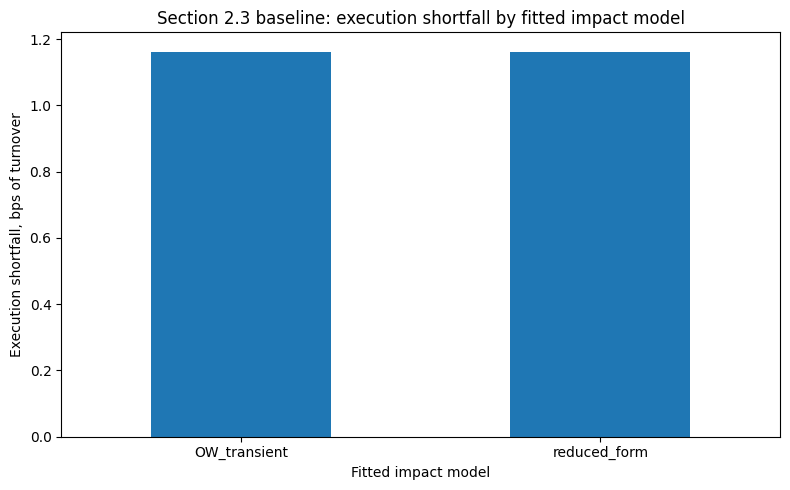

In [33]:
plot_df = summary_by_model.set_index("model")["shortfall_bps_of_turnover"].sort_index()
ax = plot_df.plot(kind="bar", figsize=(8, 5))
ax.set_title("Section 2.3 baseline: execution shortfall by fitted impact model")
ax.set_xlabel("Fitted impact model")
ax.set_ylabel("Execution shortfall, bps of turnover")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "shortfall_bps_by_model.png", dpi=150)
plt.show()

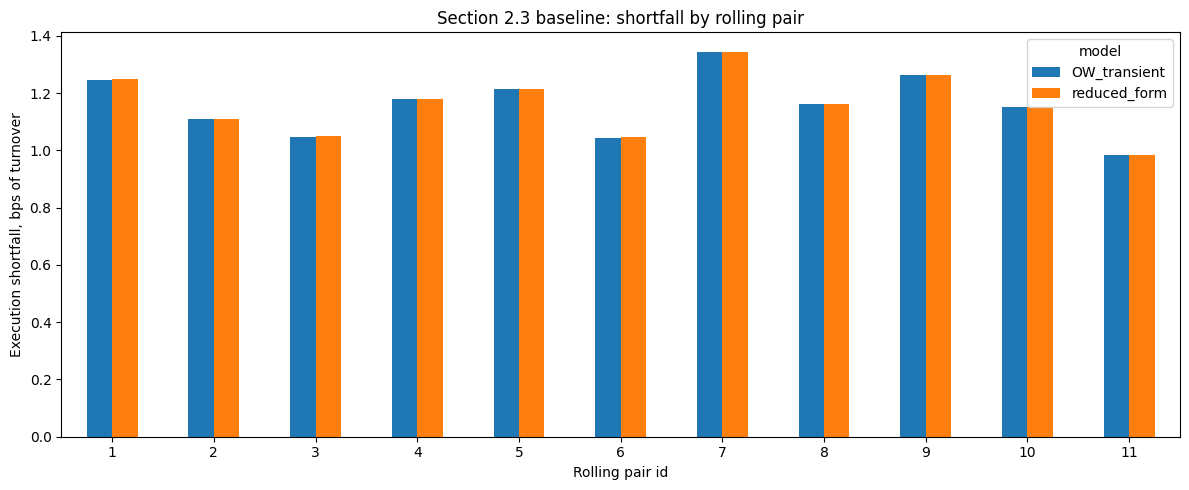

In [34]:
pair_pivot = summary_by_pair_model.pivot(index="pair_id", columns="model", values="shortfall_bps_of_turnover").sort_index()
ax = pair_pivot.plot(kind="bar", figsize=(12, 5))
ax.set_title("Section 2.3 baseline: shortfall by rolling pair")
ax.set_xlabel("Rolling pair id")
ax.set_ylabel("Execution shortfall, bps of turnover")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "shortfall_bps_by_pair_model.png", dpi=150)
plt.show()

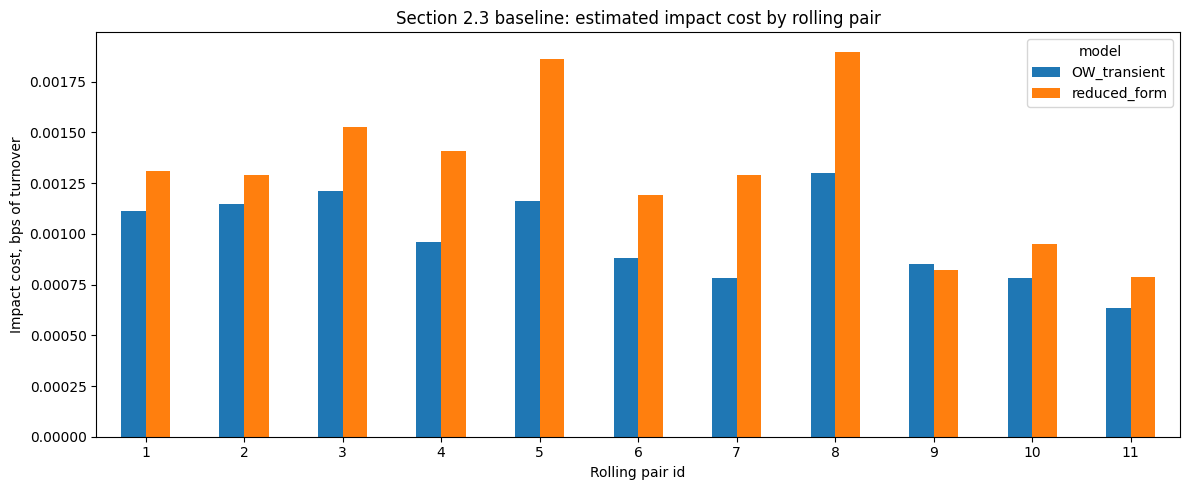

In [35]:
impact_pivot = summary_by_pair_model.pivot(index="pair_id", columns="model", values="impact_cost_bps_of_turnover").sort_index()
ax = impact_pivot.plot(kind="bar", figsize=(12, 5))
ax.set_title("Section 2.3 baseline: estimated impact cost by rolling pair")
ax.set_xlabel("Rolling pair id")
ax.set_ylabel("Impact cost, bps of turnover")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "impact_cost_bps_by_pair_model.png", dpi=150)
plt.show()

### Handoff to 2.4

In [36]:
handoff = {
    "section": "2.3 Backtest Engine rolling-universe baseline",
    "continues_from": "2.1 rolling_full_universe enhancement",
    "uses_20_stock_baseline": False,
    "uses_full_rolling_universe": True,
    "section_2_2_enhancement_used": False,
    "section_2_3_enhancement_used": False,
    "models_used_from_section_2_2": ["OW_transient", "reduced_form"],
    "backtest_sample": "out-of-sample test month for each rolling pair",
    "generic_trade_column": "our_trade",
    "baseline_daily_reset": True,
    "no_enhancement_details": [
        "No non-parametric or regularised model from Section 2.2.",
        "No multi-day carrying of impact states.",
        "No multi-day carrying of positions.",
        "No stock-split detection or exclusion logic.",
        "No alpha signal and no optimal strategy in this section.",
    ],
    "example_trade_schedule": {
        "type": "daily_round_trip",
        "participation_rate": PARTICIPATION_RATE,
        "open_window_seconds": OPEN_WINDOW_SECONDS,
        "close_window_seconds": CLOSE_WINDOW_SECONDS,
        "purpose": "baseline simulator demonstration only; not an optimal strategy",
    },
    "output_files": {
        "daily_backtest_all_pairs": str(SECTION23_DIR / "section_2_3_rolling_baseline_daily_backtest_all_pairs.csv"),
        "summary_by_model": str(REPORT_DIR / "section_2_3_summary_by_model.csv"),
        "summary_by_pair_model": str(REPORT_DIR / "section_2_3_summary_by_pair_model.csv"),
        "summary_by_stock_model": str(REPORT_DIR / "section_2_3_summary_by_stock_model.csv"),
    },
}

with open(SECTION23_DIR / "section_2_3_rolling_baseline_handoff.json", "w") as f:
    json.dump(handoff, f, indent=2)

print(json.dumps(handoff, indent=2))

{
  "section": "2.3 Backtest Engine rolling-universe baseline",
  "continues_from": "2.1 rolling_full_universe enhancement",
  "uses_20_stock_baseline": false,
  "uses_full_rolling_universe": true,
  "section_2_2_enhancement_used": false,
  "section_2_3_enhancement_used": false,
  "models_used_from_section_2_2": [
    "OW_transient",
    "reduced_form"
  ],
  "backtest_sample": "out-of-sample test month for each rolling pair",
  "generic_trade_column": "our_trade",
  "baseline_daily_reset": true,
  "no_enhancement_details": [
    "No non-parametric or regularised model from Section 2.2.",
    "No multi-day carrying of impact states.",
    "No multi-day carrying of positions.",
    "No stock-split detection or exclusion logic.",
    "No alpha signal and no optimal strategy in this section."
  ],
  "example_trade_schedule": {
    "type": "daily_round_trip",
    "participation_rate": 0.005,
    "open_window_seconds": 1800,
    "close_window_seconds": 1800,
    "purpose": "baseline simulat